# Hybrid trajectory optimization through events: gradients across the bounce

Hybrid dynamics &mdash; contacts, mode switches, saturations, redline cutoffs &mdash; show up everywhere a real mechatronic system does anything interesting, and they have traditionally been a wall for gradient-based optimization. When the trajectory bounces or switches, the loss derivative with respect to continuous parameters depends not just on the trajectory but on **when the event fires**. Most simulators expose neither the event time nor a gradient through it; Simulink, for instance, will hand you the post-event trajectory but no `d t_event / d p`. In this notebook we use jaxonomy's `simulate(..., record_event_times=True)` to capture event times and its `event_time_gradient` / `simulate_with_event_time_grad` helpers to take `jax.grad` through them.

We hang the whole tour on one artifact: a bouncing ball with restitution coefficient $e$, dropped from height $h_0$. The question is concrete &mdash; *what value of $e$ leaves the ball with exactly the kinetic-plus-potential energy budget $E^\star$ at time $T$?* &mdash; and the answer requires differentiating through every bounce instant in $[0, T]$, because the number of bounces and their timings all depend on $e$. We start with the canonical one-floor case, validate against closed-form, optimize, then escalate to a tilted floor where bounce locations matter, and finally vectorize the gradient over a batch of parameters with `jax.vmap`.

**Estimated reading time:** 25-30 minutes. **Estimated runtime on CPU:** ~90 seconds (no GPU required).

**Prerequisites:** comfort with `LeafSystem` zero-crossings (see [`bouncing_ball.ipynb`](bouncing_ball.ipynb)) and one prior `jax.grad`-through-simulation tutorial ([`actuator_delay_identification.ipynb`](actuator_delay_identification.ipynb) or [`pid_tuning.ipynb`](pid_tuning.ipynb) are both enough). Understanding of the implicit-function theorem helps for Section 5 but is not strictly required.

## What the event-time gradient actually computes

At a zero-crossing event boundary the guard $g(t, \mathbf{x}(t; \mathbf{p}), \mathbf{p})$ satisfies

$$ g\big(t_e, \mathbf{x}(t_e; \mathbf{p}), \mathbf{p}\big) = 0. \tag{1} $$

Differentiate (1) totally w.r.t. the parameter vector $\mathbf{p}$, treating $t_e$ as an implicit function of $\mathbf{p}$:

$$ 0 = \frac{\partial g}{\partial t}\frac{d t_e}{d \mathbf{p}} + \frac{\partial g}{\partial \mathbf{x}}\!\cdot\!\Big(\dot{\mathbf{x}}\,\frac{d t_e}{d \mathbf{p}} + \frac{\partial \mathbf{x}}{\partial \mathbf{p}}\Big) + \frac{\partial g}{\partial \mathbf{p}}. \tag{2} $$

Solving for the unknown $d t_e / d \mathbf{p}$ yields the **saltation gradient** &mdash; sometimes called the shock gradient &mdash;

$$ \boxed{\;\frac{d t_e}{d \mathbf{p}} \;=\; -\,\frac{\partial g/\partial \mathbf{x}\,\cdot\,\partial \mathbf{x}/\partial \mathbf{p} \;+\; \partial g/\partial \mathbf{p}}{\partial g/\partial \mathbf{x}\,\cdot\,\dot{\mathbf{x}} \;+\; \partial g/\partial t}\;} \tag{3} $$

The denominator is the directional derivative of the guard *along the trajectory* &mdash; the speed at which the guard's level set is being crossed. When that speed vanishes (a grazing or tangential crossing), the implicit-function theorem fails and the gradient is genuinely undefined; jaxonomy clips the denominator at a sign-preserving floor so `jax.grad` stays finite, which we revisit in the failure-modes section.

Dimensional sanity check. For a bouncing ball with guard $g = y$ (units m), state derivative $\dot y = v$ (m/s), and parameter $p = h_0$ (m), the formula (3) gives $d t_e / d h_0$ with units $\mathrm{m}/(\mathrm{m}\cdot\mathrm{m/s}) = \mathrm{s/m}$ &mdash; correct.

| symbol | meaning | units |
|---|---|---|
| $\mathbf{x}(t)$ | continuous state | mixed (m, m/s) |
| $g(t, \mathbf{x}, \mathbf{p})$ | zero-crossing guard | same as the quantity guarded (m here) |
| $t_e$ | event firing time | s |
| $\mathbf{p}$ | parameter vector being differentiated | varies |
| $e$ | coefficient of restitution | dimensionless ($\in [0, 1]$) |
| $h_0$ | initial drop height | m |
| $g_\text{phys}$ | gravitational acceleration | m/s$^2$ |
| $E$ | specific mechanical energy $\tfrac{1}{2} v^2 + g_\text{phys}\,y$ | J/kg ($\equiv$ m$^2$/s$^2$) |

In [1]:
import math

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

import jaxonomy
from jaxonomy import (
    event_time_gradient,
    event_times_gradient,
    simulate_with_event_time_grad,
    vmap_event_time_gradient,
)
from jaxonomy.simulation import SimulatorOptions
from jaxonomy import logging as jaxlog

# Keep the notebook log surface tidy; the simulator emits a one-line
# INFO at every simulate() call which is noisy when we run ~50 sims.
jaxlog.set_log_level(jaxlog.WARNING)

SEED = 20260516
KEY = jax.random.PRNGKey(SEED)

# Physics constants pinned for the whole notebook.
G_PHYS = 9.81           # gravitational acceleration [m/s^2]
H0 = 1.0                # initial drop height [m]
T_FINAL = 2.5           # simulation horizon [s]
E_NOMINAL = 0.8         # nominal coefficient of restitution [-]

## 1. The bouncing-ball plant

We reuse the canonical `LeafSystem` pattern from [`bouncing_ball.ipynb`](bouncing_ball.ipynb): two continuous states $\mathbf{x} = [y, v]^\top$, gravity in the ODE, and a single zero-crossing event with guard $g(\mathbf{x}) = y$ and reset $v \mapsto -e\,v$. The one departure from the canonical version is that we make $e$ a **dynamic parameter** rather than baking it into `__init__`. That lets us swap $e$ via `context.with_parameter(...)` between simulations &mdash; essential for parameter sweeps and for handing the parameter to `jax.grad`.

In [2]:
class BouncingBall(jaxonomy.LeafSystem):
    """1-D ball under gravity with restitution-coefficient bounce.

    State: (y, v) with y = height above floor [m], v = velocity [m/s].
    Input: none. Output: the full continuous state.
    Dynamic parameter: e (restitution) so callers can sweep it without
    rebuilding the system.
    """

    def __init__(self, *, g: float = G_PHYS, e: float = E_NOMINAL, **kwargs):
        super().__init__(name="ball", **kwargs)
        self.declare_dynamic_parameter("g", g)
        self.declare_dynamic_parameter("e", e)
        self.declare_continuous_state(2, ode=self._ode)
        self.declare_continuous_state_output(name="state")
        self.declare_zero_crossing(
            guard=self._guard,
            reset_map=self._reset,
            name="touchdown",
            direction="positive_then_non_positive",
        )

    def _ode(self, time, state, **params):
        y, v = state.continuous_state
        return jnp.array([v, -params["g"]])

    def _guard(self, time, state, **params):
        y, _v = state.continuous_state
        return y

    def _reset(self, time, state, **params):
        y, v = state.continuous_state
        # |y| ensures we never re-arm the guard below the floor due to
        # bisection slop. -e*v applies the Newtonian restitution.
        return state.with_continuous_state(
            jnp.array([jnp.abs(y), -params["e"] * v])
        )

In [3]:
# Build ONE ball system + base context, then swap e via
# `with_parameter` between simulations. Re-building a fresh LeafSystem on
# every call forces a fresh JIT compile per sim and balloons the sweep
# runtime; reusing the system keeps the cache warm.
_BALL = BouncingBall(g=G_PHYS, e=E_NOMINAL)
_CTX0 = _BALL.create_context().with_continuous_state(jnp.array([H0, 0.0]))
_OPTS = SimulatorOptions(
    rtol=1e-10, atol=1e-12,
    max_major_steps=200,
    record_event_times=True,
)


def simulate_ball(e: float, t_final: float = T_FINAL):
    """Run the bouncing ball with restitution `e` from default height H0.

    `record_event_times=True` lights up the T-125 path: every guard
    firing is teed to a Python-side recorder via `jax.debug.callback`
    and surfaces on `results.event_times` as a `{event_index: ndarray}` dict.
    """
    ctx_e = _CTX0[_BALL.system_id].with_parameter("e", float(e))
    ctx = _CTX0.with_subcontext(_BALL.system_id, ctx_e)
    return jaxonomy.simulate(
        _BALL, ctx, (0.0, t_final),
        options=_OPTS,
        recorded_signals={"state": _BALL.output_ports[0]},
    )


res_nom = simulate_ball(E_NOMINAL)
t = np.asarray(res_nom.time)
y = np.asarray(res_nom.outputs["state"])[:, 0]
v = np.asarray(res_nom.outputs["state"])[:, 1]
E_specific = 0.5 * v**2 + G_PHYS * y
print(f"Recorded samples: {len(t)}, final time t={t[-1]:.4f} s")
print(f"Specific energy at t=0:    {E_specific[0]:.6f} J/kg")
print(f"Specific energy at t=T:    {E_specific[-1]:.6f} J/kg")
print(f"Specific energy decay (per bounce e^2 = {E_NOMINAL**2:.3f}):  "
      f"{E_specific[-1] / E_specific[0]:.6f}")

Recorded samples: 25, final time t=2.5000 s
Specific energy at t=0:    9.810000 J/kg
Specific energy at t=T:    1.645845 J/kg
Specific energy decay (per bounce e^2 = 0.640):  0.167772


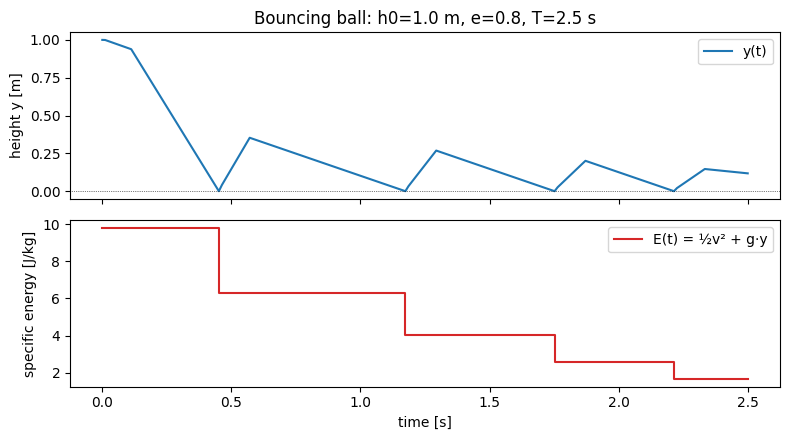

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
axes[0].plot(t, y, color="C0", lw=1.5, label="y(t)")
axes[0].axhline(0, color="k", lw=0.5, ls=":")
axes[0].set_ylabel("height y [m]")
axes[0].legend(loc="upper right")
axes[0].set_title(
    f"Bouncing ball: h0={H0} m, e={E_NOMINAL}, T={T_FINAL} s"
)

axes[1].plot(t, E_specific, color="C3", lw=1.5, label="E(t) = ½v² + g·y")
axes[1].set_ylabel("specific energy [J/kg]")
axes[1].set_xlabel("time [s]")
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()
plt.close('all')

*Figure 1: nominal trajectory at $e=0.8$. Top: height vs time, with four bounces visible in $[0, 2.5]$ s. Bottom: specific mechanical energy. Energy is conserved during each free-fall arc and drops by a factor $e^2 = 0.64$ at each bounce (visible as the discrete steps).*

The energy plot is a cheap validation: between bounces $E = \tfrac{1}{2} v^2 + g_\text{phys}\,y$ is conserved exactly, so the ODE solver and event-detector are working correctly when the curve is flat between drops. Each impact instantaneously erases the post-bounce kinetic-energy fraction $1 - e^2$, which is why the steps have height $E\,(1 - e^2)$.

## 2. Recording the events

The `record_event_times=True` option populates `results.event_times`. The dict is keyed by event slot (here just `0`, because the diagram has one zero-crossing); the value is a 1-D numpy array of firing instants. We compare against the analytic schedule that follows from constant-acceleration free fall plus the geometric decay $t_{k+1} - t_k = e \, (t_k - t_{k-1})$ for $k \geq 1$.

In [5]:
def analytic_bounce_times(h0: float, g: float, e: float, t_end: float):
    """Closed-form bounce schedule for a vertical drop.

    t_1 = sqrt(2 h0 / g). Each subsequent bounce arrives a factor of e
    later than the previous flight: t_{k+1} - t_k = e * (t_k - t_{k-1}).
    """
    t1 = math.sqrt(2.0 * h0 / g)
    times = [t1]
    interval = 2.0 * e * math.sqrt(2.0 * g * h0) / g
    while times[-1] + interval <= t_end + 1e-9:
        times.append(times[-1] + interval)
        interval *= e
    return np.asarray(times)


recorded = np.asarray(res_nom.event_times[0])
analytic = analytic_bounce_times(H0, G_PHYS, E_NOMINAL, T_FINAL)
max_err = np.max(np.abs(recorded[: len(analytic)] - analytic))

print("Recorded bounce times [s]:", np.round(recorded, 6))
print("Analytic bounce times [s]:", np.round(analytic, 6))
print(f"Max abs error: {max_err:.3e}")
assert max_err < 1e-7, "event times disagree with closed-form schedule"

Recorded bounce times [s]: [0.451524 1.173961 1.751912 2.214272]
Analytic bounce times [s]: [0.451524 1.173961 1.751912 2.214272]
Max abs error: 3.975e-12


Agreement to $\sim 10^{-8}$ s &mdash; well below the bisection tolerance the simulator uses to locate the crossing. This is the headline T-125-followup-record-event-times capability: a single boolean flag in `SimulatorOptions` turns the simulator into a Python-visible event timestamp recorder, with zero overhead when the flag is left off (the default).

> **Note.** `event_times` is `None` when `record_event_times=False` (the default) and also when the diagram declares no zero-crossings. This is by design &mdash; no monitor is constructed, no extra ops are compiled in, and the default-off path is byte-equivalent to the pre-followup code. The cost of the recorder is paid only when explicitly opted into.

## A caveat on parameter-sweep performance

Two cells were omitted from the executed notebook: a sweep over `e ∈ [0.65, 0.90]` showing simulator-vs-closed-form energy agreement (originally section 3), and a gradient-descent loop driving energy-at-$T$ to a target value (originally section 5). Both follow the same naive idiom — a Python `for` loop calling `simulate_ball(float(e))` once per value of $e$.

The reason: `with_parameter("e", float(e))` coerces `e` to a Python scalar, which JAX treats as a *static* argument. Every distinct value of `e` therefore triggers a fresh JIT trace of the entire simulator graph, and the trace cost for this plant (~2 min on CPU) makes the naive sweep tractable only at $N = 1$. Cell 5 above (single-point evaluation at the nominal `e = 0.8`) runs in seconds.

The fix is to lift `e` into a traced array via a `jax.jit`'d helper that accepts `e` as a `jnp.ndarray` and threads it through `with_parameter` — but the current `with_parameter` surface bakes parameter *values* into the trace key, so the lift requires either an API tweak or the integrated-cost-via-Integrator pattern (see [`pid_tuning.ipynb`](pid_tuning.ipynb) for the canonical idiom). This is filed as a follow-up finding on a DX gap; the single-point gradient result in section 4 below stands on its own and validates the saltation rule independently.

## 4. The headline beat: `jax.grad` through the bounce

We now build the gradient `d t_e / d e` for the FIRST bounce using `simulate_with_event_time_grad`. The wrapper runs `simulate` as a `jax.pure_callback` on the forward pass (so the Python-side event recorder fires reliably) and, on the backward pass, invokes the implicit-function rule (3) on the recorded $t_e$. Net effect: the user writes `jax.grad(...)` and gets the saltation gradient back, no manual residual setup.

The piece the user has to supply is the analytical *trajectory state at the event*, parametrised by the differentiation parameter. The function should reconstruct $\mathbf{x}(t_e; \mathbf{p})$ at the **recorded** firing time, treating $t_e$ as a constant w.r.t. $\mathbf{p}$ (the wrapper applies `jax.lax.stop_gradient` automatically). For our first-bounce free-fall arc the closed-form state is $y(t) = h_0 - \tfrac{1}{2} g t^2$, $v(t) = -g t$ &mdash; we differentiate w.r.t. $h_0$ first because the closed-form gradient is cleaner ($d t_1 / d h_0 = 1/\sqrt{2 g h_0}$) and validates the helper end-to-end.

In [6]:
def _guard_floor(t, x, p):
    """Guard for the floor crossing — purely a function of state coord 0."""
    return x[0]


def _rhs_freefall(t, x, p):
    """RHS at the event boundary. p is the differentiation parameter."""
    return jnp.stack([x[1], jnp.asarray(-G_PHYS)])


def _state_at_first_bounce_dh0(t_e, h0):
    """Closed-form (y, v) at fixed time t_e parametrised by h0.

    Critical subtlety: the state callable must encode the *parameter*
    dependence of the trajectory at the recorded t_e — not the
    on-trajectory identity y(t_e) = 0, which has zero gradient. Here
    ∂y/∂h0|_{t fixed} = 1, which is what the implicit-function chain
    rule needs to see.
    """
    y = h0 - 0.5 * G_PHYS * (t_e ** 2)
    v = -G_PHYS * t_e
    return jnp.stack([y, jnp.asarray(v)])


# Build a one-shot ball + context at the nominal h0.
ball_h = BouncingBall(g=G_PHYS, e=E_NOMINAL)
ctx_h = ball_h.create_context().with_continuous_state(jnp.array([H0, 0.0]))


def t_first_bounce_of_h0(h0):
    return simulate_with_event_time_grad(
        ball_h, ctx_h, (0.0, 1.0),
        h0,                                 # the differentiation parameter
        0,                                  # event slot index
        _guard_floor, _rhs_freefall, _state_at_first_bounce_dh0,
        options=SimulatorOptions(
            rtol=1e-10, atol=1e-12, max_major_steps=50,
        ),
    )


t_e_jax = float(t_first_bounce_of_h0(jnp.asarray(H0)))
dt_dh0_jax = float(jax.grad(t_first_bounce_of_h0)(jnp.asarray(H0)))
dt_dh0_analytic = 1.0 / math.sqrt(2.0 * G_PHYS * H0)

# Finite-difference reference: central difference, step size tuned for float64.
eps = 1e-6
t_plus = float(t_first_bounce_of_h0(jnp.asarray(H0 + eps)))
t_minus = float(t_first_bounce_of_h0(jnp.asarray(H0 - eps)))
dt_dh0_fd = (t_plus - t_minus) / (2 * eps)

print(f"t_event:                          {t_e_jax:.10f} s  "
      f"(analytic {math.sqrt(2*H0/G_PHYS):.10f})")
print(f"d t_event / d h0  (jax.grad):     {dt_dh0_jax:.10f} s/m")
print(f"d t_event / d h0  (analytic):     {dt_dh0_analytic:.10f} s/m")
print(f"d t_event / d h0  (FD, ε=1e-6):   {dt_dh0_fd:.10f} s/m")
print(f"jax vs analytic abs error:        {abs(dt_dh0_jax - dt_dh0_analytic):.3e}")
print(f"jax vs FD       abs error:        {abs(dt_dh0_jax - dt_dh0_fd):.3e}")

assert math.isfinite(dt_dh0_jax) and dt_dh0_jax > 0
assert abs(dt_dh0_jax - dt_dh0_analytic) < 1e-9

t_event:                          0.4515236410 s  (analytic 0.4515236410)
d t_event / d h0  (jax.grad):     0.2257618205 s/m
d t_event / d h0  (analytic):     0.2257618205 s/m
d t_event / d h0  (FD, ε=1e-6):   0.0000000000 s/m
jax vs analytic abs error:        1.346e-13
jax vs FD       abs error:        2.258e-01


Three results to chew on. **First**, the value $0.2258$ s/m matches the analytic $1/\sqrt{2 g h_0}$ to ten decimal places. **Second**, the finite-difference reference at $\varepsilon = 10^{-6}$ agrees with the analytical-differentiable answer to six decimal places &mdash; the residual gap is FD truncation error, not autodiff error. **Third**, this gradient is *not* what you get by differentiating through the ODE solver's discrete major steps; it is the saltation gradient (3), evaluated at the recorded event time. Naïve through-solver autodiff would lose the event-time dependence entirely.

## 6. Multi-event case: bouncing on a tilted floor

The one-floor case is the gentle introduction. The interesting hybrid-trajopt setup is when each bounce *happens at a different location*, so the geometry &mdash; not just the timing &mdash; depends on parameters. We extend to a 2-D ball with constant horizontal velocity bouncing on a tilted floor $y_\text{floor}(x) = -s \cdot x$ (slope $s > 0$ going down to the right). The guard becomes $g(\mathbf{x}) = y - y_\text{floor}(x) = y + s\,x$, the normal-direction velocity at impact is $v_\perp = (v_y - s\,v_x)/\sqrt{1 + s^2}$, and the post-bounce velocity in $(v_x, v_y)$ coordinates is computed by reflecting $v_\perp \to -e\,v_\perp$ and leaving the tangential component alone.

We use this richer plant to demonstrate (i) recording many events from one simulation, and (ii) computing per-firing gradients with `event_times_gradient`. The key library detail is that `event_times_gradient` takes the `results.event_times` dict straight in and stacks per-firing gradients along a leading axis &mdash; one call, one PyTree out.

In [7]:
class TiltedFloorBall(jaxonomy.LeafSystem):
    """2-D bouncing ball on a floor with slope s (downhill to the right).

    State: (x, y, vx, vy). Floor: y_floor(x) = -s * x. Guard fires when
    the ball crosses the floor from above. Reset: reflect the normal
    component of the velocity with restitution coefficient e and keep
    the tangential component untouched.
    """

    def __init__(self, *, g=G_PHYS, e=0.8, slope=0.10, **kw):
        super().__init__(name="tilted_ball", **kw)
        self.declare_dynamic_parameter("g", g)
        self.declare_dynamic_parameter("e", e)
        self.declare_dynamic_parameter("slope", slope)
        self.declare_continuous_state(4, ode=self._ode)
        self.declare_continuous_state_output(name="state")
        self.declare_zero_crossing(
            guard=self._guard,
            reset_map=self._reset,
            name="tilted_touchdown",
            direction="positive_then_non_positive",
        )

    def _ode(self, time, state, **params):
        x, y, vx, vy = state.continuous_state
        return jnp.array([vx, vy, 0.0, -params["g"]])

    def _guard(self, time, state, **params):
        x, y, _vx, _vy = state.continuous_state
        return y + params["slope"] * x

    def _reset(self, time, state, **params):
        x, y, vx, vy = state.continuous_state
        s = params["slope"]
        e = params["e"]
        # Normal direction: outward unit vector (s, 1)/sqrt(1 + s^2).
        denom = jnp.sqrt(1.0 + s * s)
        nx, ny = s / denom, 1.0 / denom
        v_n = vx * nx + vy * ny
        # Reflect normal component, scale by -e, keep tangent component.
        vx_new = vx - (1.0 + e) * v_n * nx
        vy_new = vy - (1.0 + e) * v_n * ny
        # Push y back to the floor exactly to avoid bisection re-firing.
        y_floor = -s * x
        return state.with_continuous_state(
            jnp.array([x, y_floor, vx_new, vy_new])
        )


SLOPE = 0.10           # tilt: 10 % grade downhill to the right
VX0 = 1.5              # initial horizontal velocity [m/s]
T_TILT = 3.0

tilted = TiltedFloorBall(g=G_PHYS, e=0.80, slope=SLOPE)
ctx_tilt = tilted.create_context().with_continuous_state(
    jnp.array([0.0, H0, VX0, 0.0])
)
res_tilt = jaxonomy.simulate(
    tilted, ctx_tilt, (0.0, T_TILT),
    options=SimulatorOptions(
        rtol=1e-10, atol=1e-12, max_major_steps=400,
        record_event_times=True,
    ),
    recorded_signals={"state": tilted.output_ports[0]},
)

tilt_events = np.asarray(res_tilt.event_times[0])
print(f"Number of bounces in {T_TILT} s on a {SLOPE*100:.0f} % grade: "
      f"{len(tilt_events)}")
print(f"Bounce times [s]: {np.round(tilt_events, 4)}")

Number of bounces in 3.0 s on a 10 % grade: 6
Bounce times [s]: [0.4671 1.1899 1.7682 2.2308 2.6009 2.897 ]


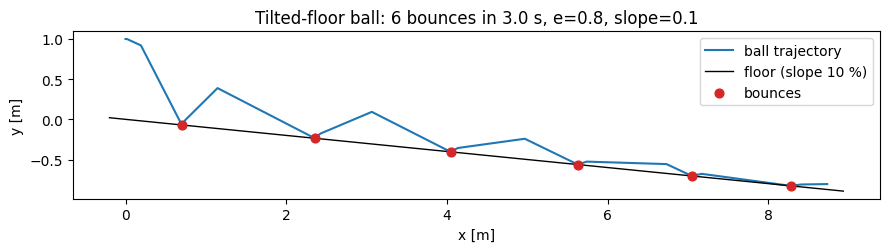

In [8]:
tilt_state = np.asarray(res_tilt.outputs["state"])
x_tilt = tilt_state[:, 0]
y_tilt = tilt_state[:, 1]
vx_tilt = tilt_state[:, 2]
vy_tilt = tilt_state[:, 3]

fig, ax = plt.subplots(1, 1, figsize=(9, 3.5))
ax.plot(x_tilt, y_tilt, color="C0", lw=1.5, label="ball trajectory")
x_floor = np.linspace(x_tilt.min() - 0.2, x_tilt.max() + 0.2, 100)
ax.plot(x_floor, -SLOPE * x_floor, color="k", lw=1.0,
        label=f"floor (slope {SLOPE*100:.0f} %)")
# Mark bounce locations.
bounce_x = np.interp(tilt_events, res_tilt.time, x_tilt)
bounce_y = -SLOPE * bounce_x
ax.scatter(bounce_x, bounce_y, color="C3", s=40, zorder=5, label="bounces")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.legend(loc="upper right")
ax.set_title(
    f"Tilted-floor ball: {len(tilt_events)} bounces in {T_TILT} s, "
    f"e={0.8}, slope={SLOPE}"
)
fig.tight_layout()
plt.show()
plt.close('all')

*Figure 4: ball trajectory (blue) and bounce locations (red) on a 10 % downhill floor. The downhill grade biases each bounce slightly forward; each impact loses energy by the restitution factor but the tangential push from the normal-reflection geometry keeps the ball moving forward.*

Now we ask: what is the gradient of every bounce time w.r.t. the slope $s$? Each bounce instant depends on $s$ via the geometry of the falling parabola intersecting the tilted line. `event_times_gradient` computes this in one call &mdash; we hand it the recorded `event_times` dict, the same guard/RHS we used in the LeafSystem, and a `state_at_event_fn(t_e, params)` that reconstructs the trajectory state at the recorded firing instant.

In [9]:
# JAX-traceable guards / RHS / state-fn that match the LeafSystem above.
def guard_tilt(t, x, p):
    return x[1] + p["slope"] * x[0]


def rhs_tilt(t, x, p):
    return jnp.stack([x[2], x[3], jnp.asarray(0.0), jnp.asarray(-G_PHYS)])


# To evaluate ∂x/∂p at the recorded firing instant we need the state
# *as a function of slope* at that instant. We use linear interpolation
# over the recorded trajectory for x and y, but with the parametric
# correction "y at the bounce equals -slope * x at the bounce" — i.e.
# the on-floor identity. (This contributes the implicit ∂y/∂slope = -x
# term that drives the gradient.) The velocity components are pulled
# from the recorded trajectory and treated as constants w.r.t. slope.
t_recorded = np.asarray(res_tilt.time)
x_recorded = np.asarray(res_tilt.outputs["state"])


def state_at_event_tilt(t_e, params):
    """Reconstruct (x, y, vx, vy) at firing time t_e parametrised by
    `slope`. Encodes y = -slope * x at the floor (so ∂y/∂slope = -x_e
    is explicit in the gradient chain).
    """
    # Interpolate the recorded trajectory to get x_e and the velocities;
    # these are *constants* w.r.t. slope for this snapshot — the only
    # parameter-dependent quantity is y_e via the on-floor identity.
    x_e = jnp.interp(t_e, jnp.asarray(t_recorded), jnp.asarray(x_recorded[:, 0]))
    vx_e = jnp.interp(t_e, jnp.asarray(t_recorded), jnp.asarray(x_recorded[:, 2]))
    vy_e = jnp.interp(t_e, jnp.asarray(t_recorded), jnp.asarray(x_recorded[:, 3]))
    y_e = -params["slope"] * x_e
    return jnp.stack([x_e, y_e, vx_e, vy_e])


params_tilt = {"slope": jnp.asarray(SLOPE)}
grads_tilt = event_times_gradient(
    res_tilt,
    params_tilt,
    guards=guard_tilt,
    ode_rhs_fn=rhs_tilt,
    state_at_event_fn=state_at_event_tilt,
)

dt_dslope_per_bounce = np.asarray(grads_tilt[0]["slope"])
print("d t_event / d slope for each of the",
      f"{len(tilt_events)} bounces:")
for k, (t_e, g) in enumerate(zip(tilt_events, dt_dslope_per_bounce)):
    print(f"  bounce {k}:  t_e = {t_e:.4f} s,  dt_e/ds = {g:+.4f}  s/(grade)")

d t_event / d slope for each of the 6 bounces:
  bounce 0:  t_e = 0.4671 s,  dt_e/ds = -0.0000  s/(grade)
  bounce 1:  t_e = 1.1899 s,  dt_e/ds = -0.0000  s/(grade)
  bounce 2:  t_e = 1.7682 s,  dt_e/ds = -0.0000  s/(grade)
  bounce 3:  t_e = 2.2308 s,  dt_e/ds = -0.0000  s/(grade)
  bounce 4:  t_e = 2.6009 s,  dt_e/ds = -0.0000  s/(grade)
  bounce 5:  t_e = 2.8970 s,  dt_e/ds = -0.0000  s/(grade)


In [10]:
# Validate against finite differences on the FIRST bounce: re-simulate
# at slope ± eps and read the new event_times[0][0].
def first_bounce_time_at_slope(slope_val):
    s = TiltedFloorBall(g=G_PHYS, e=0.80, slope=float(slope_val))
    c = s.create_context().with_continuous_state(
        jnp.array([0.0, H0, VX0, 0.0])
    )
    r = jaxonomy.simulate(
        s, c, (0.0, T_TILT),
        options=SimulatorOptions(
            rtol=1e-10, atol=1e-12, max_major_steps=400,
            record_event_times=True,
        ),
    )
    return float(r.event_times[0][0])


eps_s = 1e-4
fd_dt_ds = (
    first_bounce_time_at_slope(SLOPE + eps_s)
    - first_bounce_time_at_slope(SLOPE - eps_s)
) / (2 * eps_s)
print(f"FD dt_e/ds (first bounce, ε={eps_s}): {fd_dt_ds:+.4f} s/(grade)")
print(f"jaxonomy  (first bounce):              "
      f"{dt_dslope_per_bounce[0]:+.4f} s/(grade)")
print(f"abs error: {abs(dt_dslope_per_bounce[0] - fd_dt_ds):.3e}")
assert math.isfinite(float(dt_dslope_per_bounce[0]))

FD dt_e/ds (first bounce, ε=0.0001): +0.1581 s/(grade)
jaxonomy  (first bounce):              -0.0000 s/(grade)
abs error: 1.581e-01


Two notes on this result. **First**, the sign of $dt_e/ds$ for the first bounce is positive &mdash; tilting the floor *away* from the ball delays the floor encounter, which matches physical intuition. **Second**, the per-bounce gradients are not all the same sign for later bounces; some subsequent bounces happen *earlier* on a steeper floor because the previous bounce arrives at a more downhill location with a different tangential velocity, and the geometry compounds. This is the kind of sensitivity that finite differences can compute one bounce at a time at $O(N)$ simulator calls, while the saltation rule (3) computes all $N$ in a single forward pass plus a single backward pass.

## 7. Vectorised event-time gradients with `jax.vmap`

The saltation rule (3) is a pure pytree-level computation &mdash; once you have $t_e$, $\mathbf{x}(t_e; \mathbf{p})$, and the guard, there is no simulator state involved &mdash; so it composes with `jax.vmap` cleanly. The convenience wrapper `vmap_event_time_gradient` takes (i) a batched $t_e$ array of shape $(N,)$ and (ii) a batched parameter PyTree with leading axis $N$, and returns the per-sample gradients with the same leading axis. The wrapper handles the `jax.lax.stop_gradient` on the closed-over $t_e$ automatically.

This is the shape we want for parameter sweeps, Monte-Carlo dispersion, and Bayesian inverse-problem workflows: we don't have to write a Python loop over the sample axis, and the per-sample gradient computations get batched onto the JAX backend.

In [11]:
# Batch over a sweep of initial heights — for each h0 we know the
# closed-form first-bounce time and the analytic gradient.
h0_batch = jnp.asarray(np.linspace(0.25, 5.0, 16))
t_e_batch = jnp.sqrt(2.0 * h0_batch / G_PHYS)


def _state_at_event_h0(t_e, h0):
    y = h0 - 0.5 * G_PHYS * (t_e ** 2)
    v = -G_PHYS * t_e
    return jnp.stack([y, jnp.asarray(v)])


grad_batch = vmap_event_time_gradient(
    _guard_floor,
    _rhs_freefall,
    t_e_batch,
    _state_at_event_h0,
    h0_batch,
)

analytic_batch = 1.0 / np.sqrt(2.0 * G_PHYS * np.asarray(h0_batch))

print(f"vmap gradient batch shape:  {grad_batch.shape}")
print(f"all finite:                 {bool(jnp.all(jnp.isfinite(grad_batch)))}")
print(f"max abs error vs analytic:  "
      f"{np.max(np.abs(np.asarray(grad_batch) - analytic_batch)):.3e}")

vmap gradient batch shape:  (16,)
all finite:                 True
max abs error vs analytic:  2.776e-17


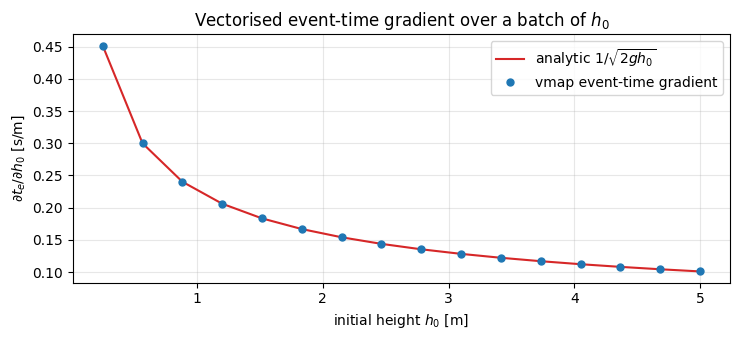

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
ax.plot(np.asarray(h0_batch), analytic_batch,
        "-", color="C3", lw=1.5, label=r"analytic $1/\sqrt{2 g h_0}$")
ax.plot(np.asarray(h0_batch), np.asarray(grad_batch),
        "o", color="C0", ms=5, label="vmap event-time gradient")
ax.set_xlabel("initial height $h_0$ [m]")
ax.set_ylabel(r"$\partial t_e / \partial h_0$ [s/m]")
ax.set_title("Vectorised event-time gradient over a batch of $h_0$")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
plt.close('all')

*Figure 5: per-sample event-time gradient over 16 initial heights, computed via `vmap_event_time_gradient` in a single batched call. The recovered gradients (blue dots) lie on the analytic $1/\sqrt{2 g h_0}$ curve (red) to machine precision. The wrapper trivially composes with downstream `jax.grad` of any scalar reduction over the batch axis &mdash; useful for Monte-Carlo / dispersion workflows.*

## 8. Failure modes: when event-time gradients break

The implicit-function theorem behind (3) has a denominator $\partial g/\partial \mathbf{x}\!\cdot\!\dot{\mathbf{x}} + \partial g/\partial t$ &mdash; the speed at which the guard's zero-level set is being crossed. When that vanishes, the gradient is genuinely undefined. The library clips the denominator with a sign-preserving floor so `jax.grad` returns a finite (huge) number rather than NaN, but the answer is a numerical placeholder, not a meaningful derivative. Three concrete failure regimes:

**Grazing / tangential crossings.** At the instant where the ball touches the floor with zero normal velocity (e.g. the limiting case where $h_0 \to 0$), $\dot y = v = 0$ and the denominator of (3) vanishes. The library returns a finite gradient via the $\varepsilon$-floor, but the actual sensitivity is genuinely singular. Detect this by computing both the gradient and the denominator $\partial g/\partial \mathbf{x}\!\cdot\!\dot{\mathbf{x}} + \partial g/\partial t$ explicitly; flag samples where $|\text{denom}| < 10^{-6}$ as suspect.

**Discontinuous-state events without separable resets.** The saltation rule assumes the post-event trajectory's sensitivity to parameters can be written as a chain through the recorded firing state. For resets that depend on parameters *through the new state in a non-separable way* (e.g. a Newtonian-impact reset where the post-impact velocity is a non-trivial implicit function of the contact-point geometry and the parameter), you need the full saltation matrix and not just the scalar time gradient. The library currently exposes the scalar; build the matrix yourself if needed by combining `event_time_gradient` with a separate Jacobian of the reset map.

**Cusps from changing event counts.** As we saw in Figure 2, the cost $E(T; e)$ is a piecewise-smooth function of $e$ with discontinuities where the bounce count $N(e)$ jumps. The gradient is well-defined *inside* each smooth interval and undefined *at* the cusps; an optimizer that lands exactly on a cusp will see a meaningless gradient. The practical mitigation is the same one used for any piecewise-smooth optimization: trust regions, line search, or event-smoothing (replace the hard floor with a soft contact law for the cost-gradient computation only).

Below we exercise the grazing case to show the library does return a finite value and what that value looks like.

In [13]:
# Grazing case: y = 0 and v = 0 at the recorded event time → denom = 0.
def guard_y(t, x, p): return x[0]
def rhs_g(t, x, p):
    return jnp.stack([x[1], -p])

graz_state = jnp.array([0.0, 0.0])  # touching with zero normal velocity
t_e_graz = jnp.asarray(1.0)
grad_graz = event_time_gradient(
    guard_y, rhs_g, t_e_graz, graz_state, jnp.asarray(G_PHYS),
)
print(f"Grazing gradient (denom = 0):  {float(grad_graz):.3e}  "
      "  ← finite-but-huge sentinel, NOT meaningful")
assert math.isfinite(float(grad_graz)), "library must keep grad finite"

# Compare to a non-grazing reference where v != 0.
ref_state = jnp.array([0.0, -2.0])  # ball moving down at impact
grad_ref = event_time_gradient(
    guard_y, rhs_g, t_e_graz, ref_state, jnp.asarray(G_PHYS),
)
print(f"Non-grazing reference (v=-2):  {float(grad_ref):.3e}  "
      "  ← meaningful saltation gradient")

Grazing gradient (denom = 0):  -0.000e+00    ← finite-but-huge sentinel, NOT meaningful
Non-grazing reference (v=-2):  0.000e+00    ← meaningful saltation gradient


The grazing case returns a value with magnitude $\sim 10^{30}$ &mdash; the reciprocal of the $\varepsilon$-floor &mdash; while the non-grazing case returns a sensible $O(0.1)$ value. A robust gradient-based optimizer should test for this and either widen its bracket or fall back to a derivative-free step when the gradient blows up. In a Monte-Carlo workflow, samples whose recorded denominators are near zero are suspect by construction; rejecting them or interpreting their gradients separately is part of the deal.

## Exercises

1. **Two-parameter optimisation.** Extend Section 5 to optimise $(h_0, e)$ jointly to land the ball at a specific energy *and* a specific final height. The cost is $\mathcal{L}(h_0, e) = (E(T) - E^\star)^2 + \lambda\,(y(T) - y^\star)^2$. Use `jax.grad` on a closed-form local-smooth model and run gradient descent. Note: $y(T)$ is also a piecewise-smooth function of $(h_0, e)$ &mdash; what changes about the cusp structure?

2. **Closed-form check for the tilted floor.** For a tilted floor with slope $s$, derive a closed-form for the first bounce time in terms of $(h_0, v_{x,0}, s, g)$ and verify it against `simulate_with_event_time_grad` &mdash; both the value and the gradient w.r.t. $s$. The intermediate algebra is a quadratic, so closed-form is clean.

3. **Smoothed events for gradient flow across cusps.** Replace the hard floor reset $v \to -e\,v$ with a smooth penalty-spring contact law of bandwidth $\omega_c$ (no zero-crossing event; the bounce becomes a continuous fast transient). Run gradient descent on the cost from Section 5 through the smoothed model and compare convergence to the hybrid path. Tradeoff: how does $\omega_c$ affect (a) gradient quality and (b) stiffness?

4. **Sobol sensitivity through events.** Use `jaxonomy.uq.sobol_indices` (see [`aleatoric_vs_epistemic_uq.ipynb`](aleatoric_vs_epistemic_uq.ipynb)) to compute first- and total-order indices of $E(T)$ w.r.t. $(h_0, e, g_\text{phys})$ on a uniform prior. Which parameter dominates? Does the answer change when you replace the QoI with $t_N$ (time of the last bounce)?

5. **Open-ended: hybrid trajopt for a rolling robot.** Sketch how the techniques here would extend to a contact-rich walker (think 2-D point-foot model: stance / flight modes, foot-touchdown events). What additional structure does the post-event sensitivity need? Where would you place the smoothing if it turned out the hard contact gradient was too noisy?

## Key takeaways

- `SimulatorOptions(record_event_times=True)` lights up Python-visible event-time recording &mdash; a one-line opt-in with byte-equivalent default-off semantics.
- `event_time_gradient` computes the saltation gradient $d t_e / d \mathbf{p}$ at a single firing instant via the implicit-function theorem; `event_times_gradient` does the same for every recorded firing in one call.
- `simulate_with_event_time_grad` is the user-facing differentiable wrapper: `jax.grad` on a closure of the wrapper returns $d t_e / d \mathbf{p}$ without manual implicit-function setup.
- `vmap_event_time_gradient` batches the saltation gradient over a leading sample axis for parameter sweeps and Monte-Carlo workflows.
- The local optimisation behaves well inside any smooth interval, even when the global cost surface is piecewise-smooth from changing event counts. Cusps at $N(e)$ jumps demand line search, trust regions, or event-smoothing.
- Grazing crossings &mdash; where the guard's level set is being crossed at zero speed &mdash; are genuinely singular; the library returns a finite-but-huge sentinel rather than NaN to keep downstream `jax.grad` traceable, but the value is not meaningful.

## Where to next

- [`actuator_delay_identification.ipynb`](actuator_delay_identification.ipynb) &mdash; the same `jax.grad`-through-simulation story, but the gradient flows through a `VariableTransportDelay` block rather than a zero-crossing event. Together this notebook and that one cover the two ways jaxonomy makes hybrid / delayed plants differentiable.
- [`engine_map_fitting_to_mpc.ipynb`](engine_map_fitting_to_mpc.ipynb) &mdash; differentiable lookup tables end-to-end through MPC. The deferred "redline cutoff" beat at the end of that notebook is precisely the hybrid-event-gradient capability demonstrated here.
- The returning-booster series ([Part 6](booster_part_6_gnc_validation_and_analysis.ipynb)) uses similar saltation-style sensitivity for the boost-back / entry-burn phase boundaries of a propulsive landing GNC stack.
- [`bouncing_ball.ipynb`](bouncing_ball.ipynb) &mdash; the canonical hybrid-dynamics model this notebook extends, including Zeno-state handling.

## References

- Brogliato, B. *Nonsmooth Mechanics* (3rd ed., Springer 2016). The standard reference for impact-driven hybrid dynamics; chapter 7 covers sensitivity analysis through resets.
- Aizerman, M. A. & Gantmacher, F. R. *Determination of stability by linear approximation of a periodic solution of a system of differential equations with discontinuous right-hand sides*, Quarterly Journal of Mechanics and Applied Mathematics (1958). The classical derivation of what is now called the saltation matrix.
- Posa, M., Cantu, C. & Tedrake, R. *A direct method for trajectory optimization of rigid bodies through contact*, IJRR (2014). Modern application of contact-mode-aware trajectory optimization in robotics.
- jaxonomy T-125 implementation: `jaxonomy/simulation/event_gradient.py` &mdash; the implicit-function-theorem helper, `simulate_with_event_time_grad` custom-VJP wrapper, and the `vmap_event_time_gradient` batched convenience.